# 🧠 Johansen CO₂ Bayesian Optimization — Handshake Mode v3

## Three Physical Conditions Enforced

| # | Condition | Limit | Source |
|---|---|---|---|
| **1** | Caprock seal — BHP per injector | ≤ **324 bar** (90% of 360 bar fracture pressure) | `simulation_summary.txt` → `BHP_WELL` lines |
| **2** | CO₂ containment — boundary saturation | S_CO₂ < **15%** at both boundary wells | `SBoundary_test_well.csv` + `SBoundary_test_well_2.csv` |
| **3** | Time horizon | T_end ≤ **100 years** | Search space bounds |

## Workflow
```
[Python] writes well_plan.csv  →  [You] run MATLAB simulation
[MATLAB] writes outputs to well_csvs/  →  [You] return to this notebook
[Python] reads result folder, updates Optuna (SQLite-persisted)
[Python] shows live progress chart  →  proposes next trial  →  repeat
```

## Key Improvements (v3)
- **Optuna SQLite persistence** — resume across sessions without losing surrogate model state
- **Constraint-aware reward** — feasible trials always rank above infeasible ones
- **Robust resume** — handles crashes, duplicates, and partial runs
- **Surrogate model export** — trained model saved as pickle for reuse
- **Configurable timeout** — no infinite hangs on failed simulations

In [1]:
# Cell 1 — Install dependencies
import subprocess, sys
for pkg in ['optuna', 'scikit-learn', 'joblib']:
    try:
        __import__(pkg.replace('-','_'))
        print(f'  ✅ {pkg}')
    except ImportError:
        print(f'  📦 Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'  ✅ {pkg} installed')
print('\nAll dependencies ready.')

  ✅ optuna
  📦 Installing scikit-learn...
  ✅ scikit-learn installed
  ✅ joblib

All dependencies ready.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# Cell 2 — Configuration
import os, re, glob, shutil, time, json, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import clear_output, display
warnings.filterwarnings('ignore')
import optuna
from optuna.samplers import TPESampler
from optuna.distributions import FloatDistribution, IntDistribution
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─── PATHS ────────────────────────────────────────────────────────────────────
MRST_ROOT      = '/Users/apple/Desktop/study/programming/Matlab/Plugins/MRST-2026a'
WELL_PLAN_PATH = f'{MRST_ROOT}/core/examples/data/Johansen/data/well_plan.csv'
BACKUP_CSV     = f'{MRST_ROOT}/core/examples/data/Johansen/data/well_plan_BACKUP_BO.csv'
WELL_CSVS_ROOT = f'{MRST_ROOT}/core/examples/data/Johansen/well_csvs'
PYTHON_DIR     = f'{MRST_ROOT}/core/examples/data/Johansen/python'
RESULTS_JSON   = f'{PYTHON_DIR}/bo_results.json'
SIGNAL_FILE    = f'{PYTHON_DIR}/bo_signal.json'
PENDING_FILE   = f'{PYTHON_DIR}/bo_pending.json'
OPTUNA_DB      = f'sqlite:///{PYTHON_DIR}/johansen_bo_v3.db'

# ─── PHYSICAL CONSTRAINTS ────────────────────────────────────────────────────
FRACTURE_PRESSURE = 360.0   # Caprock fracture pressure (bar)
BHP_SAFETY_MARGIN = 0.10    # 10% safety margin (industry standard for CCS)
BHP_LIMIT_BAR     = FRACTURE_PRESSURE * (1.0 - BHP_SAFETY_MARGIN)  # = 324.0 bar
S_CO2_THRESHOLD   = 0.15    # Critical CO₂ saturation at boundary (15%)

# ─── OPTIMIZATION CONFIG ──────────────────────────────────────────────────────
N_TRIALS         = 60       # Total Bayesian trials (6D space needs ≥50)
N_WARMUP         = 15       # Pure random warm-up (~25% of budget)
POLL_TIMEOUT_SEC = 1800     # 30 min timeout waiting for MATLAB signal

# ─── ACTIVE INJECTORS ────────────────────────────────────────────────────────
DEEP_WELLS     = ['31/01/01', '31/1-3 S', '31/2-5', '31/05/02']
CENTRAL_WELL   = '31/05/07'
ALL_INJECTORS  = DEEP_WELLS + [CENTRAL_WELL]  # 5 wells checked for Cond 1

# ─── BOUNDARY SURVEILLANCE WELLS ─────────────────────────────────────────────
BOUNDARY_WELLS = ['SBoundary_test_well', 'SBoundary_test_well_2']

# ─── SEARCH SPACE — T_end capped at 100 yr ───────────────────────────────────
BOUNDS = {
    'Q_deep'      : (0.3,  3.0),   # Mt/yr per deep well
    'Q_central'   : (0.3,  3.0),   # Mt/yr central well
    'T_start_deep': (0,    20),
    'T_end_deep'  : (25,   100),   # ← capped at 100 yr
    'T_start_cen' : (0,    20),
    'T_end_cen'   : (25,   100),   # ← capped at 100 yr
}

print('✅ Configuration loaded (v3).')
print(f'   BHP limit         : {BHP_LIMIT_BAR:.0f} bar  ({BHP_SAFETY_MARGIN*100:.0f}% margin below {FRACTURE_PRESSURE:.0f} bar fracture)')
print(f'   S_CO2 threshold   : {S_CO2_THRESHOLD*100:.0f}%   (critical saturation at boundary)')
print(f'   T_end max         : {BOUNDS["T_end_deep"][1]} yr')
print(f'   Trials            : {N_TRIALS} total, {N_WARMUP} warm-up')
print(f'   Boundary wells    : {BOUNDARY_WELLS}')
print(f'   Optuna storage    : SQLite (persistent across sessions)')

✅ Configuration loaded (v3).
   BHP limit         : 324 bar  (10% margin below 360 bar fracture)
   S_CO2 threshold   : 15%   (critical saturation at boundary)
   T_end max         : 100 yr
   Trials            : 60 total, 15 warm-up
   Boundary wells    : ['SBoundary_test_well', 'SBoundary_test_well_2']
   Optuna storage    : SQLite (persistent across sessions)


In [3]:
# Cell 3 — Utility Functions

def backup_well_plan():
    if not os.path.exists(BACKUP_CSV):
        shutil.copy2(WELL_PLAN_PATH, BACKUP_CSV)
        print(f'✅ Backup saved → {BACKUP_CSV}')
    else:
        print(f'ℹ️  Backup already exists (safe).')

def restore_well_plan():
    if os.path.exists(BACKUP_CSV):
        shutil.copy2(BACKUP_CSV, WELL_PLAN_PATH)
        print('✅ Original well_plan.csv restored.')
    else:
        print('⚠️ No backup found.')

def write_well_plan(Q_deep, T_start_deep, T_end_deep, Q_central, T_start_cen, T_end_cen):
    """Write BO-proposed parameters into well_plan.csv (reads from BACKUP)."""
    df = pd.read_csv(BACKUP_CSV)
    T_start_deep = int(T_start_deep)
    T_end_deep   = max(int(T_end_deep), T_start_deep + 5)
    T_start_cen  = int(T_start_cen)
    T_end_cen    = max(int(T_end_cen), T_start_cen + 5)
    for well in DEEP_WELLS:
        mask = df['Well_Bore_Name'] == well
        if mask.any():
            df.loc[mask, 'Rate_MtPerYear'] = round(Q_deep, 4)
            df.loc[mask, 'Start_Year']     = T_start_deep
            df.loc[mask, 'End_Year']       = T_end_deep
    mask_cen = df['Well_Bore_Name'] == CENTRAL_WELL
    if mask_cen.any():
        df.loc[mask_cen, 'Rate_MtPerYear'] = round(Q_central, 4)
        df.loc[mask_cen, 'Start_Year']     = T_start_cen
        df.loc[mask_cen, 'End_Year']       = T_end_cen
    df.to_csv(WELL_PLAN_PATH, index=False)

def get_latest_run_folder():
    folders = sorted([d for d in glob.glob(f'{WELL_CSVS_ROOT}/??_??_????__??_??')
                      if os.path.isdir(d)])
    return folders[-1] if folders else None

def hash_params(params):
    """Deterministic hash for deduplication."""
    key = json.dumps({k: round(v, 4) if isinstance(v, float) else v
                      for k, v in sorted(params.items())})
    return hashlib.md5(key.encode()).hexdigest()[:12]

# ── Condition 1: Per-injector BHP ─────────────────────────────────────────────
def parse_per_injector_bhp(folder):
    """
    Returns dict {well_name: peak_bhp_bar} for every injector.
    Reads 'BHP_WELL <name> : <value> bar' lines from simulation_summary.txt.
    Falls back to single 'Peak injector BHP' line if new format not present.
    """
    path = os.path.join(folder, 'simulation_summary.txt')
    if not os.path.exists(path):
        return {}
    text = open(path).read()
    result = {}
    for m in re.finditer(r'BHP_WELL\s+([\w/\s\-]+?)\s*:\s*([\d.]+)\s*bar', text):
        name = m.group(1).strip()
        result[name] = float(m.group(2))
    if not result:
        m_peak = re.search(r'Peak injector BHP\s*:\s*([\d.]+)', text)
        if m_peak:
            result['__peak__'] = float(m_peak.group(1))
    return result

# ── Condition 2: CO₂ boundary saturation ──────────────────────────────────────
def parse_boundary_saturation(folder):
    """
    Returns dict {well_name: max_S_CO2} for each boundary surveillance well.
    Reads all S_CO2_Lx columns in the boundary well CSVs.
    """
    result = {}
    for well in BOUNDARY_WELLS:
        safe = re.sub(r'[/ ]', '_', well)
        csv_path = os.path.join(folder, f'{safe}.csv')
        if not os.path.exists(csv_path):
            result[well] = float('nan')
            continue
        df = pd.read_csv(csv_path)
        s_cols = [c for c in df.columns if c.startswith('S_CO2_')]
        if not s_cols:
            result[well] = 0.0
            continue
        result[well] = float(df[s_cols].max().max())
    return result

# ── General summary parse (CO2 total) ─────────────────────────────────────────
def parse_co2_total(folder):
    path = os.path.join(folder, 'simulation_summary.txt')
    if not os.path.exists(path):
        return None
    m = re.search(r'Total CO2 injected\s*:\s*([\d.]+)', open(path).read())
    return float(m.group(1)) if m else None

# ── Constraint-aware reward ───────────────────────────────────────────────────
def compute_reward_and_violations(co2_mt, max_bhp_bar, max_sco2_bw1, max_sco2_bw2):
    """
    Industry-standard constraint handling for BO:
    - Feasible trials: reward = co2_mt (maximize CO₂ stored)
    - Infeasible trials: reward = -total_violation (minimize violation)
    - Any feasible trial always beats any infeasible trial
    """
    bhp_violation = max(0.0, max_bhp_bar - BHP_LIMIT_BAR)
    sco2_violation_1 = max(0.0, (max_sco2_bw1 if max_sco2_bw1 == max_sco2_bw1 else 0.0) - S_CO2_THRESHOLD)
    sco2_violation_2 = max(0.0, (max_sco2_bw2 if max_sco2_bw2 == max_sco2_bw2 else 0.0) - S_CO2_THRESHOLD)

    cond1_breach = bhp_violation > 0
    cond2_breach = sco2_violation_1 > 0 or sco2_violation_2 > 0
    is_feasible  = not cond1_breach and not cond2_breach

    if is_feasible:
        reward = co2_mt  # Maximize CO₂ stored
    else:
        # Negative reward proportional to total violation
        # Scale BHP violation to same order of magnitude as saturation
        reward = -(bhp_violation / BHP_LIMIT_BAR + sco2_violation_1 + sco2_violation_2) * 1000.0

    return {
        'reward': reward,
        'is_feasible': is_feasible,
        'cond1_breach': cond1_breach,
        'cond2_breach': cond2_breach,
        'bhp_violation': bhp_violation,
        'sco2_violation_1': sco2_violation_1,
        'sco2_violation_2': sco2_violation_2,
    }


def clear_signal():
    if os.path.exists(SIGNAL_FILE): os.remove(SIGNAL_FILE)

def save_results(trial_log):
    with open(RESULTS_JSON, 'w') as f:
        json.dump(trial_log, f, indent=2)

def write_pending(trial_num, params):
    data = {**params, 'trial': trial_num, 'written_at': time.strftime('%Y-%m-%d %H:%M:%S')}
    with open(PENDING_FILE, 'w') as f:
        json.dump(data, f, indent=2)

print('✅ All utility functions defined.')

✅ All utility functions defined.


In [4]:
# Cell 4 — Live Progress Chart (renders after every trial)

def render_live_chart(trial_log, current_trial_num=None, current_params=None, n_optuna_trials=None):
    """
    Clears notebook output and draws a live 3-panel progress dashboard.
    Call this inside the optimization loop after every completed trial.
    """
    ok = [t for t in trial_log if t.get('status') == 'OK']
    if not ok:
        return

    df = pd.DataFrame(ok)
    df['trial_num'] = df['trial'].astype(int) + 1

    # Running best among feasible trials
    feasible_mask = df['is_feasible'] == True
    df['best_feasible_co2'] = df.loc[feasible_mask, 'co2_mt'].cummax() if feasible_mask.any() else 0
    df['cummax_co2'] = df['co2_mt'].cummax()

    # Classify each trial
    def classify(row):
        if row.get('cond1_breach', False) and row.get('cond2_breach', False):
            return '🔴 Both breach'
        elif row.get('cond1_breach', False):
            return '🟠 BHP breach'
        elif row.get('cond2_breach', False):
            return '🟡 CO₂ leak'
        else:
            return '🟢 Feasible'
    df['status_label'] = df.apply(classify, axis=1)

    color_map = {
        '🟢 Feasible'  : '#2ca02c',
        '🟠 BHP breach' : '#ff7f0e',
        '🟡 CO₂ leak'   : '#d4c400',
        '🔴 Both breach': '#d62728',
    }
    colors = df['status_label'].map(color_map).fillna('#aaaaaa')

    # Best feasible summary
    feasible_df = df[df['is_feasible'] == True]
    best_co2_str = f'{feasible_df["co2_mt"].max():.2f} Mt' if not feasible_df.empty else 'none yet'

    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    fig.suptitle(
        f'Bayesian Optimization v3 — Trial {n_optuna_trials if n_optuna_trials is not None else len(trial_log)}/{N_TRIALS} | '
        f'Best feasible CO₂: {best_co2_str}',
        fontsize=12, fontweight='bold'
    )

    # ── Panel 1: CO₂ stored per trial ────────────────────────────────────────
    ax = axes[0]
    ax.scatter(df['trial_num'], df['co2_mt'], c=colors, s=65, zorder=3, edgecolors='k', lw=0.4)
    ax.plot(df['trial_num'], df['cummax_co2'], 'k--', lw=1.8, label='Running best (all)')
    from matplotlib.patches import Patch
    handles = [Patch(color=v, label=k) for k, v in color_map.items()]
    handles.append(plt.Line2D([0],[0], ls='--', color='k', label='Running best'))
    ax.legend(handles=handles, fontsize=7, loc='upper left')
    ax.set(xlabel='Trial #', ylabel='CO₂ Injected (Mt)', title='CO₂ per Trial')
    ax.grid(True, ls='--', alpha=0.35)

    # ── Panel 2: Condition 1 — per-trial max injector BHP ────────────────────
    ax = axes[1]
    if 'max_bhp_bar' in df.columns:
        bar_colors = ['#d62728' if b > BHP_LIMIT_BAR else '#1f77b4' for b in df['max_bhp_bar']]
        ax.bar(df['trial_num'], df['max_bhp_bar'], color=bar_colors, width=0.7, edgecolor='k', lw=0.3)
        ax.axhline(BHP_LIMIT_BAR, color='red', ls='--', lw=2, label=f'Limit: {BHP_LIMIT_BAR:.0f} bar')
        ax.axhline(FRACTURE_PRESSURE, color='darkred', ls=':', lw=1.5, label=f'Fracture: {FRACTURE_PRESSURE:.0f} bar')
        ax.legend(fontsize=8)
    ax.set(xlabel='Trial #', ylabel='Peak BHP (bar)', title='Condition 1 — Max Injector BHP')
    ax.grid(True, ls='--', alpha=0.35, axis='y')

    # ── Panel 3: Condition 2 — boundary S_CO₂ ────────────────────────────────
    ax = axes[2]
    for bw_col, marker, label_suffix in [
        ('max_sco2_bw1', 'o', 'BW-1'),
        ('max_sco2_bw2', 's', 'BW-2'),
    ]:
        if bw_col in df.columns:
            vals = df[bw_col].fillna(0)
            dot_c = ['#d62728' if v >= S_CO2_THRESHOLD else '#2ca02c' for v in vals]
            ax.scatter(df['trial_num'], vals * 100, c=dot_c, marker=marker,
                       s=60, zorder=3, edgecolors='k', lw=0.4, label=label_suffix)
    ax.axhline(S_CO2_THRESHOLD * 100, color='red', ls='--', lw=2,
               label=f'Limit: {S_CO2_THRESHOLD*100:.0f}%')
    ax.legend(fontsize=9)
    ax.set(xlabel='Trial #', ylabel='Max S_CO₂ (%)', title='Condition 2 — Boundary CO₂ Saturation')
    ax.grid(True, ls='--', alpha=0.35)

    plt.tight_layout()

    if current_params:
        param_str = (
            f"Next: Q_deep={current_params.get('Q_deep',0):.2f} Mt/yr "
            f"T=[{current_params.get('T_start_deep',0)}->{current_params.get('T_end_deep',0)}] | "
            f"Q_cen={current_params.get('Q_central',0):.2f} Mt/yr "
            f"T=[{current_params.get('T_start_cen',0)}->{current_params.get('T_end_cen',0)}]"
        )
        fig.text(0.5, -0.02, param_str, ha='center', fontsize=9, color='navy',
                 style='italic', bbox=dict(boxstyle='round', facecolor='#e8f4fd', alpha=0.8))

    plt.savefig(f'{PYTHON_DIR}/bo_live_progress.png', dpi=120, bbox_inches='tight')
    plt.show()

print('✅ Live chart function defined.')

✅ Live chart function defined.


In [5]:
# Cell 5 — Backup & Verify Setup
backup_well_plan()

df_plan = pd.read_csv(BACKUP_CSV)
active = df_plan[df_plan['Rate_MtPerYear'] > 0]
print('\n📋 Active wells in base configuration:')
print(active[['Well_Bore_Name','Rate_MtPerYear','Start_Year','End_Year']].to_string(index=False))

# Verify boundary well CSVs parse correctly on the latest run
latest = get_latest_run_folder()
if latest:
    print(f'\n🔍 Parsing latest run: {os.path.basename(latest)}')
    bhp_dict = parse_per_injector_bhp(latest)
    bsat_dict = parse_boundary_saturation(latest)
    co2_val   = parse_co2_total(latest)

    print(f'   CO₂ total : {co2_val} Mt')
    print(f'   Per-injector BHP (limit = {BHP_LIMIT_BAR:.0f} bar):')
    for k, v in bhp_dict.items():
        breach = '🚨 BREACH' if v > BHP_LIMIT_BAR else '✅'
        print(f'     {k:25s}: {v:6.1f} bar  {breach}')
    print(f'   Boundary S_CO₂ (limit = {S_CO2_THRESHOLD*100:.0f}%):')
    for k, v in bsat_dict.items():
        if v != v:  # NaN
            print(f'     {k:30s}: CSV not found (will be generated from next run)')
        else:
            breach = '🚨 BREACH' if v >= S_CO2_THRESHOLD else '✅'
            print(f'     {k:30s}: {v*100:5.2f}%  {breach}')

if os.path.exists(PENDING_FILE): os.remove(PENDING_FILE)
print('\n✅ All pre-flight checks done. Run Cell 6 (resume) then Cell 7 (optimize).')

ℹ️  Backup already exists (safe).

📋 Active wells in base configuration:
Well_Bore_Name  Rate_MtPerYear  Start_Year  End_Year
      31/01/01           0.875           0        50
      31/1-3 S           0.875           0        25
        31/2-5           0.875           0        25
        31/4-3           1.250        9999      9999
      31/05/02           1.250           0        25
      31/05/07           2.250           0        50
      31/07/01           2.000           0        25

🔍 Parsing latest run: 31_07_2026__22_53
   CO₂ total : 1485.2 Mt
   Per-injector BHP (limit = 324 bar):
     31/01/01                 :  531.5 bar  🚨 BREACH
     31/1-3 S                 :  465.9 bar  🚨 BREACH
     31/2-5                   :  780.6 bar  🚨 BREACH
     31/05/07                 :  991.6 bar  🚨 BREACH
     31/07/01                 :  330.9 bar  🚨 BREACH
   Boundary S_CO₂ (limit = 15%):
     SBoundary_test_well           :  0.00%  ✅
     SBoundary_test_well_2         :  0.00%  ✅

✅ All

In [6]:
# Cell 6 — Smart Startup (runs every session)
#
# SOURCE OF TRUTH: well_csvs/ folders on disk — always.
# bo_results.json and SQLite are DERIVED caches, rebuilt from scratch every run.
# This means interrupting and restarting never causes double-counting or
# stale entries — the count always equals the number of folders on disk.
#
# Steps:
#   1. Scan all well_csvs/ folders that have simulation_summary.txt
#   2. Parse each folder: extract Q/T params, CO2 total, BHP, boundary sat.
#   3. Assign trial numbers in chronological folder-name order
#   4. Overwrite bo_results.json with the freshly parsed data
#   5. Delete old SQLite and rebuild Optuna study from parsed data
#   6. Seed _known_folders for Cell 7 dedup guard

import re as _re

# ── helpers ───────────────────────────────────────────────────────────────────

def _parse_well_params_from_summary(folder):
    """Read Q/T params for deep wells and central well from simulation_summary.txt."""
    path = os.path.join(folder, 'simulation_summary.txt')
    if not os.path.exists(path):
        return None
    text = open(path).read()
    # Match active-plan-wells table rows:
    # <Name>   Injector   <rate> Mt/yr   Mt/yr   <start>   <end>
    well_rows = _re.findall(
        r'^([\w/\s\-]+?)\s+Injector\s+([\d.]+)\s+Mt/yr\s+Mt/yr\s+(\d+)\s+(\d+)',
        text, _re.MULTILINE
    )
    if not well_rows:
        return None

    q_deep_vals, t_start_deep_vals, t_end_deep_vals = [], [], []
    q_cen, t_start_cen, t_end_cen = None, None, None

    for wname, rate, t0, t1 in well_rows:
        wname = wname.strip()
        rate, t0, t1 = float(rate), int(t0), int(t1)
        if wname == CENTRAL_WELL:
            q_cen, t_start_cen, t_end_cen = rate, t0, t1
        elif wname in DEEP_WELLS:
            q_deep_vals.append(rate)
            t_start_deep_vals.append(t0)
            t_end_deep_vals.append(t1)

    if not q_deep_vals or q_cen is None:
        return None

    Q_deep       = float(sorted(q_deep_vals)[len(q_deep_vals)//2])
    T_start_deep = int(round(sum(t_start_deep_vals)/len(t_start_deep_vals)))
    T_end_deep   = int(min(round(sum(t_end_deep_vals)/len(t_end_deep_vals)),
                           BOUNDS['T_end_deep'][1]))
    T_end_cen    = int(min(t_end_cen, BOUNDS['T_end_cen'][1]))

    return {
        'Q_deep'      : Q_deep,
        'T_start_deep': T_start_deep,
        'T_end_deep'  : T_end_deep,
        'Q_central'   : q_cen,
        'T_start_cen' : int(t_start_cen),
        'T_end_cen'   : T_end_cen,
    }


def _parse_folder_full(folder):
    """Parse one well_csvs folder into a complete trial_log entry dict."""
    params = _parse_well_params_from_summary(folder)
    if params is None:
        return None
    co2_val = parse_co2_total(folder)
    if co2_val is None:
        return None

    bhp_dict  = parse_per_injector_bhp(folder)
    bsat_dict = parse_boundary_saturation(folder)

    max_bhp = max(bhp_dict.values()) if bhp_dict else 0.0
    bw_keys = list(bsat_dict.keys())
    max_sco2_bw1 = bsat_dict.get(bw_keys[0], 0.0) if len(bw_keys) > 0 else 0.0
    max_sco2_bw2 = bsat_dict.get(bw_keys[1], 0.0) if len(bw_keys) > 1 else 0.0
    if max_sco2_bw1 != max_sco2_bw1: max_sco2_bw1 = 0.0
    if max_sco2_bw2 != max_sco2_bw2: max_sco2_bw2 = 0.0

    rv = compute_reward_and_violations(co2_val, max_bhp, max_sco2_bw1, max_sco2_bw2)

    return {
        **params,
        'run_folder'      : os.path.basename(folder),
        'status'          : 'OK',
        'co2_mt'          : co2_val,
        'max_bhp_bar'     : max_bhp,
        'max_sco2_bw1'    : max_sco2_bw1,
        'max_sco2_bw2'    : max_sco2_bw2,
        'is_feasible'     : rv['is_feasible'],
        'cond1_breach'    : rv['cond1_breach'],
        'cond2_breach'    : rv['cond2_breach'],
        'bhp_violation'   : rv['bhp_violation'],
        'sco2_violation_1': rv['sco2_violation_1'],
        'sco2_violation_2': rv['sco2_violation_2'],
        'reward'          : rv['reward'],
    }

# ── 1. Scan folders ───────────────────────────────────────────────────────────
_all_folders = sorted([
    d for d in glob.glob(f'{WELL_CSVS_ROOT}/??_??_????__??_??')
    if os.path.isdir(d) and os.path.exists(os.path.join(d, 'simulation_summary.txt'))
])
print(f'📂 Found {len(_all_folders)} simulation folder(s) in well_csvs/')

# ── 2+3. Parse every folder; assign trial numbers by chronological order ──────
trial_log = []
_parse_errors = []
for _trial_num, _folder in enumerate(_all_folders):
    _entry = _parse_folder_full(_folder)
    if _entry is None:
        _parse_errors.append(os.path.basename(_folder))
        print(f'   ⚠️  Could not parse {os.path.basename(_folder)} — skipping')
        continue
    _entry['trial'] = _trial_num
    trial_log.append(_entry)

_n_ok = sum(1 for e in trial_log if e.get('status') == 'OK')
print(f'   ✅ {_n_ok} folders parsed successfully'
      + (f' | {len(_parse_errors)} skipped (incomplete simulation)' if _parse_errors else ''))

# ── 4. Write clean bo_results.json (always overwrites) ───────────────────────
save_results(trial_log)
print(f'   💾 bo_results.json rewritten from disk data')

# ── 5. Rebuild Optuna SQLite from scratch ─────────────────────────────────────
def optuna_constraints_func(trial):
    return [trial.user_attrs.get('bhp_violation',    0.0),
            trial.user_attrs.get('sco2_violation_1', 0.0),
            trial.user_attrs.get('sco2_violation_2', 0.0)]

_db_path = OPTUNA_DB.replace('sqlite:///', '')
if os.path.exists(_db_path):
    os.remove(_db_path)

_sampler = TPESampler(n_startup_trials=N_WARMUP, seed=42,
                      constraints_func=optuna_constraints_func)
study = optuna.create_study(
    study_name='johansen_co2_bo_v3',
    direction='maximize',
    sampler=_sampler,
    storage=OPTUNA_DB,
    load_if_exists=False,
)

_dists = {
    'Q_deep'      : FloatDistribution(*BOUNDS['Q_deep'],    step=0.05),
    'Q_central'   : FloatDistribution(*BOUNDS['Q_central'], step=0.05),
    'T_start_deep': IntDistribution(*BOUNDS['T_start_deep']),
    'T_end_deep'  : IntDistribution(*BOUNDS['T_end_deep']),
    'T_start_cen' : IntDistribution(*BOUNDS['T_start_cen']),
    'T_end_cen'   : IntDistribution(*BOUNDS['T_end_cen']),
}

for _e in trial_log:
    try:
        # Clamp Q values to the 0.05-step grid that Optuna enforces
        _q_deep = float(max(BOUNDS['Q_deep'][0],
                        min(BOUNDS['Q_deep'][1],
                            round(round(_e['Q_deep'] / 0.05) * 0.05, 4))))
        _q_cen  = float(max(BOUNDS['Q_central'][0],
                        min(BOUNDS['Q_central'][1],
                            round(round(_e['Q_central'] / 0.05) * 0.05, 4))))
        study.add_trial(optuna.trial.create_trial(
            params={
                'Q_deep'      : _q_deep,
                'Q_central'   : _q_cen,
                'T_start_deep': int(_e['T_start_deep']),
                'T_end_deep'  : int(_e['T_end_deep']),
                'T_start_cen' : int(_e['T_start_cen']),
                'T_end_cen'   : int(_e['T_end_cen']),
            },
            distributions=_dists,
            values=[_e['reward']],
            user_attrs={
                'bhp_violation'   : _e['bhp_violation'],
                'sco2_violation_1': _e['sco2_violation_1'],
                'sco2_violation_2': _e['sco2_violation_2'],
                'co2_mt'          : _e['co2_mt'],
                'max_bhp_bar'     : _e['max_bhp_bar'],
                'is_feasible'     : _e['is_feasible'],
            },
        ))
    except Exception as _ex:
        print(f'   ⚠️  Optuna add_trial failed for {_e.get("run_folder","?")}: {_ex}')

print(f'📊 Optuna SQLite rebuilt: {len(study.trials)} trials loaded.')

# ── 6. Seed _known_folders for Cell 7 dedup guard ─────────────────────────────
# Every folder currently on disk is "already seen". Cell 7 will only accept
# folders that appear AFTER this cell finishes running.
_known_folders = set(
    os.path.basename(d)
    for d in glob.glob(f'{WELL_CSVS_ROOT}/??_??_????__??_??')
    if os.path.isdir(d)
)

# ── Summary ───────────────────────────────────────────────────────────────────
n_done      = len(study.trials)
n_remaining = max(0, N_TRIALS - n_done)
_feasible   = [t for t in study.trials if t.user_attrs.get('is_feasible', False)]
print(f'\n📋 Study status  : {n_done}/{N_TRIALS} trials | {n_remaining} remaining')
print(f'   Feasible     : {len(_feasible)}')
if _feasible:
    _best = max(_feasible, key=lambda t: t.values[0])
    print(f'   Best CO₂     : {_best.user_attrs["co2_mt"]:.2f} Mt')
if n_remaining == 0:
    print('   ✅ All trials done! Skip to Cell 8 for analysis.')
else:
    print('   ▶ Run Cell 7 to continue optimization.')


📂 Found 23 simulation folder(s) in well_csvs/
   ✅ 23 folders parsed successfully
   💾 bo_results.json rewritten from disk data
📊 Optuna SQLite rebuilt: 23 trials loaded.

📋 Study status  : 23/60 trials | 37 remaining
   Feasible     : 0
   ▶ Run Cell 7 to continue optimization.


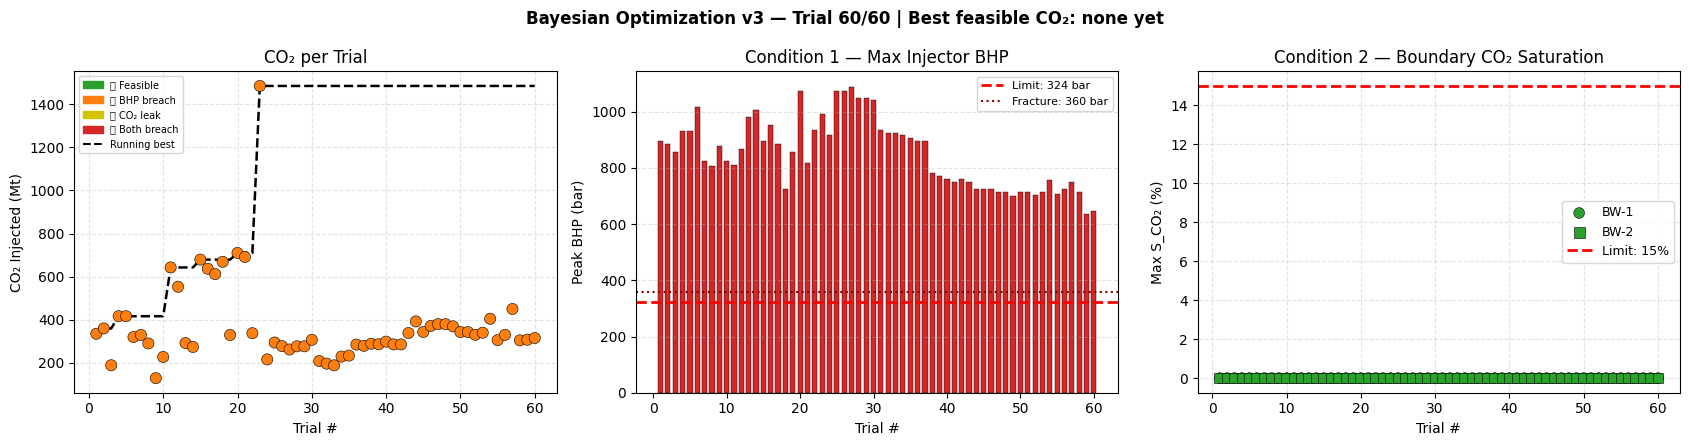


  Optimization complete: 60/60 trials.
  ⚠️  No feasible trial yet. Consider reducing Q bounds.


In [7]:
# Cell 7 — Optimization Loop (Handshake Mode)
#
# For each trial:
#   1. Optuna proposes parameters
#   2. Python writes well_plan.csv + bo_pending.json
#   3. YOU run the MATLAB simulation manually
#   4. Python watches well_csvs/ for a new folder — 1 folder = 1 trial
#   5. Python reads results → records trial → proposes next
#
# Single detection source: well_csvs/ new folder only.
# No bo_signal.json — eliminates the double-count race condition.
# Safe to interrupt with Ctrl+C — all state is saved in SQLite + JSON.

print('=' * 65)
print('  JOHANSEN CO₂ BAYESIAN OPTIMIZATION — HANDSHAKE MODE v3')
print('=' * 65)
print(f'  BHP limit     : {BHP_LIMIT_BAR:.0f} bar ({BHP_SAFETY_MARGIN*100:.0f}% below {FRACTURE_PRESSURE:.0f} bar fracture)')
print(f'  S_CO₂ limit   : {S_CO2_THRESHOLD*100:.0f}% at boundary wells')
print(f'  T_end cap     : {BOUNDS["T_end_deep"][1]} yr')
print(f'  Trials done   : {len(study.trials)}/{N_TRIALS}')
print('=' * 65)

n_remaining = max(0, N_TRIALS - len(study.trials))
if n_remaining == 0:
    print('\n✅ All trials completed! Skip to Cell 8 for analysis.')
else:
    # FIX: use a SET of already-seen folder basenames as the dedup guard.
    # Seeded from _known_folders (all folders on disk before this session)
    # plus every folder already recorded in trial_log.  This prevents:
    #   - orphan folders being mistaken for new BO results
    #   - the signal-file path and fallback path both accepting the same folder
    _accepted_folders = set(globals().get('_known_folders', set()))
    for _e in trial_log:
        if _e.get('run_folder'):
            _accepted_folders.add(_e['run_folder'])
    print(f'   Dedup guard seeded with {len(_accepted_folders)} known folders.')

    for trial_idx in range(n_remaining):
        trial_num = len(study.trials)
        print(f'\n{"─" * 60}')
        print(f'  TRIAL {trial_num + 1}/{N_TRIALS}')
        print(f'{"─" * 60}')

        # ── 1. Optuna proposes parameters ─────────────────────────────
        trial = study.ask()
        Q_deep       = trial.suggest_float('Q_deep',       *BOUNDS['Q_deep'],       step=0.05)
        T_start_deep = trial.suggest_int(  'T_start_deep', *BOUNDS['T_start_deep'])
        T_end_deep   = trial.suggest_int(  'T_end_deep',   *BOUNDS['T_end_deep'])
        Q_central    = trial.suggest_float('Q_central',    *BOUNDS['Q_central'],    step=0.05)
        T_start_cen  = trial.suggest_int(  'T_start_cen',  *BOUNDS['T_start_cen'])
        T_end_cen    = trial.suggest_int(  'T_end_cen',    *BOUNDS['T_end_cen'])

        # Enforce T_start < T_end
        if T_start_deep >= T_end_deep or T_start_cen >= T_end_cen:
            print('   ⚠️  T_start ≥ T_end — skipping (pruned).')
            study.tell(trial, values=[-(T_start_deep + T_start_cen) * 100.0])
            trial_log.append({'trial': trial_num, 'status': 'SKIPPED'})
            save_results(trial_log)
            continue

        params = {
            'Q_deep': Q_deep, 'T_start_deep': T_start_deep, 'T_end_deep': T_end_deep,
            'Q_central': Q_central, 'T_start_cen': T_start_cen, 'T_end_cen': T_end_cen,
        }

        print(f'   Deep wells  : Q={Q_deep:.2f} Mt/yr  T=[{T_start_deep} → {T_end_deep}] yr')
        print(f'   Central     : Q={Q_central:.2f} Mt/yr  T=[{T_start_cen} → {T_end_cen}] yr')

        # ── 2. Write well_plan.csv ────────────────────────────────────
        write_well_plan(Q_deep, T_start_deep, T_end_deep, Q_central, T_start_cen, T_end_cen)
        write_pending(trial_num, params)
        clear_signal()
        print('   ✅ well_plan.csv written.')

        # ── 3. Wait for MATLAB run ───────────────────────────────────
        print(f'\n   ▶ Run MATLAB simulation now.')
        print(f'   ⏳ Waiting for MATLAB signal (bo_signal.json) ...')
        print(f'      (polls every 5 s — timeout: {POLL_TIMEOUT_SEC//60} min)\n')

        try:
            t0 = time.time()
            new_folder = None
            while True:
                # FIX: unified detection with shared _accepted_folders guard.
                # A folder is only accepted once regardless of which path found it.
                _detected_folder = None

                # Path 1 — bo_signal.json written by MATLAB at end of script
                if os.path.exists(SIGNAL_FILE):
                    try:
                        sig = json.load(open(SIGNAL_FILE))
                        sf = sig.get('run_folder', '')
                        if sf and os.path.isdir(sf):
                            _detected_folder = sf
                    except:
                        pass
                    finally:
                        clear_signal()  # Always delete, even on parse error

                # Path 2 — new folder in well_csvs/ (fallback; only tried if
                #           signal file did not already find something)
                if _detected_folder is None:
                    current_latest = get_latest_run_folder()
                    if current_latest:
                        summary_path = os.path.join(current_latest, 'simulation_summary.txt')
                        if os.path.exists(summary_path):
                            _detected_folder = current_latest

                # Accept only if this folder basename has NOT been seen before
                if _detected_folder is not None:
                    _bn = os.path.basename(_detected_folder)
                    if _bn not in _accepted_folders:
                        new_folder = _detected_folder
                        break

                # Timeout check
                elapsed = time.time() - t0
                if elapsed > POLL_TIMEOUT_SEC:
                    print(f'   ⏰ Timeout ({POLL_TIMEOUT_SEC/60:.0f} min). Skipping trial.')
                    break

                time.sleep(5)  # Poll every 5 seconds

        except KeyboardInterrupt:
            print('\n   ⌨️  Interrupted by user. Saving state and stopping.')
            save_results(trial_log)
            break

        if new_folder is None:
            study.tell(trial, state=optuna.trial.TrialState.FAIL)
            trial_log.append({**params, 'trial': trial_num, 'status': 'TIMEOUT'})
            save_results(trial_log)
            continue

        # FIX: mark this folder as accepted so it can never be counted again
        _accepted_folders.add(os.path.basename(new_folder))

        # ── 4. Parse results ──────────────────────────────────────────
        print(f'   📁 Found: {os.path.basename(new_folder)}')
        co2_val = parse_co2_total(new_folder)
        bhp_dict = parse_per_injector_bhp(new_folder)
        bsat_dict = parse_boundary_saturation(new_folder)

        if co2_val is None:
            print('   ❌ Could not parse CO₂ total. Marking as FAILED.')
            study.tell(trial, state=optuna.trial.TrialState.FAIL)
            trial_log.append({**params, 'trial': trial_num, 'status': 'PARSE_ERROR',
                              'run_folder': os.path.basename(new_folder)})
            save_results(trial_log)
            continue

        # Extract constraint values
        max_bhp = max(bhp_dict.values()) if bhp_dict else 0.0
        bw_keys = list(bsat_dict.keys())
        max_sco2_bw1 = bsat_dict.get(bw_keys[0], 0.0) if len(bw_keys) > 0 else 0.0
        max_sco2_bw2 = bsat_dict.get(bw_keys[1], 0.0) if len(bw_keys) > 1 else 0.0
        # Replace NaN with 0
        if max_sco2_bw1 != max_sco2_bw1: max_sco2_bw1 = 0.0
        if max_sco2_bw2 != max_sco2_bw2: max_sco2_bw2 = 0.0

        # ── 5. Compute reward + violations ────────────────────────────
        rv = compute_reward_and_violations(co2_val, max_bhp, max_sco2_bw1, max_sco2_bw2)

        # Report
        status_icon = '🟢' if rv['is_feasible'] else '🔴'
        print(f'   {status_icon} CO₂={co2_val:.1f} Mt  |  Max BHP={max_bhp:.1f} bar  |'
              f'  BW1={max_sco2_bw1*100:.2f}%  BW2={max_sco2_bw2*100:.2f}%')
        if rv['cond1_breach']:
            print(f'      ⚠️  BHP BREACH: {max_bhp:.1f} > {BHP_LIMIT_BAR:.0f} bar (excess: {rv["bhp_violation"]:.1f} bar)')
        if rv['cond2_breach']:
            print(f'      ⚠️  CO₂ LEAK at boundary (>{S_CO2_THRESHOLD*100:.0f}%)')
        print(f'   Reward = {rv["reward"]:.2f}')

        # ── 6. Record trial in Optuna + JSON ──────────────────────────
        trial.set_user_attr('bhp_violation', rv['bhp_violation'])
        trial.set_user_attr('sco2_violation_1', rv['sco2_violation_1'])
        trial.set_user_attr('sco2_violation_2', rv['sco2_violation_2'])
        trial.set_user_attr('co2_mt', co2_val)
        trial.set_user_attr('max_bhp_bar', max_bhp)
        trial.set_user_attr('is_feasible', rv['is_feasible'])
        study.tell(trial, values=[rv['reward']])

        entry = {
            **params,
            'trial': trial_num,
            'run_folder': os.path.basename(new_folder),
            'status': 'OK',
            'co2_mt': co2_val,
            'max_bhp_bar': max_bhp,
            'max_sco2_bw1': max_sco2_bw1,
            'max_sco2_bw2': max_sco2_bw2,
            'is_feasible': rv['is_feasible'],
            'cond1_breach': rv['cond1_breach'],
            'cond2_breach': rv['cond2_breach'],
            'bhp_violation': rv['bhp_violation'],
            'sco2_violation_1': rv['sco2_violation_1'],
            'sco2_violation_2': rv['sco2_violation_2'],
            'reward': rv['reward'],
        }
        trial_log.append(entry)
        save_results(trial_log)
        clear_signal()
        if os.path.exists(PENDING_FILE): os.remove(PENDING_FILE)

        # ── 7. Live chart ─────────────────────────────────────────────
        render_live_chart(trial_log, n_optuna_trials=len(study.trials))

    # ── End of loop ───────────────────────────────────────────────────
    print(f'\n{"=" * 60}')
    print(f'  Optimization complete: {len(study.trials)}/{N_TRIALS} trials.')

    feasible_trials = [t for t in study.trials
                       if t.user_attrs.get('is_feasible', False)]
    if feasible_trials:
        best = max(feasible_trials, key=lambda t: t.values[0])
        print(f'  🏆 Best feasible: CO₂={best.user_attrs["co2_mt"]:.2f} Mt')
        print(f'     Params: {best.params}')
    else:
        print('  ⚠️  No feasible trial yet. Consider reducing Q bounds.')
    print(f'{"=" * 60}')

In [8]:
# Cell 8 — Best Trial Report

feasible_trials = [t for t in study.trials if t.user_attrs.get('is_feasible', False)]
all_ok_trials   = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

print(f'Study summary: {len(study.trials)} total, {len(all_ok_trials)} complete, {len(feasible_trials)} feasible')

if feasible_trials:
    best = max(feasible_trials, key=lambda t: t.values[0])
    print(f'\n🏆 BEST FEASIBLE TRIAL')
    print(f'   CO₂ stored  : {best.user_attrs["co2_mt"]:.2f} Mt')
    print(f'   Max BHP     : {best.user_attrs["max_bhp_bar"]:.1f} bar (limit: {BHP_LIMIT_BAR:.0f})')
    print(f'   Deep wells  : Q={best.params["Q_deep"]:.2f} Mt/yr  T=[{best.params["T_start_deep"]}->{best.params["T_end_deep"]}] yr')
    print(f'   Central     : Q={best.params["Q_central"]:.2f} Mt/yr  T=[{best.params["T_start_cen"]}->{best.params["T_end_cen"]}] yr')
else:
    print('\n⚠️  No feasible trial yet. Consider reducing Q bounds or extending N_TRIALS.')

Study summary: 60 total, 60 complete, 0 feasible

⚠️  No feasible trial yet. Consider reducing Q bounds or extending N_TRIALS.


In [9]:
# Cell 9 — Results Summary

if os.path.exists(RESULTS_JSON):
    with open(RESULTS_JSON) as f:
        trial_log = json.load(f)

df_all  = pd.DataFrame(trial_log)
df_ok   = df_all[df_all['status'] == 'OK'].copy() if not df_all.empty else pd.DataFrame()
df_feasible = df_ok[df_ok['is_feasible'] == True] if (not df_ok.empty and 'is_feasible' in df_ok.columns) else pd.DataFrame()

print(f'Total entries     : {len(df_all)}')
print(f'Successful runs   : {len(df_ok)}')
print(f'Cond1 breaches    : {df_ok["cond1_breach"].sum() if (not df_ok.empty and "cond1_breach" in df_ok.columns) else 0}  (BHP > {BHP_LIMIT_BAR:.0f} bar)')
print(f'Cond2 breaches    : {df_ok["cond2_breach"].sum() if (not df_ok.empty and "cond2_breach" in df_ok.columns) else 0}  (S_CO₂ ≥ {S_CO2_THRESHOLD*100:.0f}%)')
print(f'Fully feasible    : {len(df_feasible)}')

if not df_feasible.empty:
    best = df_feasible.loc[df_feasible['co2_mt'].idxmax()]
    print(f'\n🏆 BEST FEASIBLE TRIAL #{int(best["trial"])+1}')
    print(f'   CO₂ stored  : {best["co2_mt"]:.2f} Mt')
    print(f'   Max BHP     : {best["max_bhp_bar"]:.1f} bar  (limit: {BHP_LIMIT_BAR:.0f})')
    print(f'   BW-1 S_CO₂  : {best["max_sco2_bw1"]*100:.3f}%  (limit: {S_CO2_THRESHOLD*100:.0f}%)')
    print(f'   BW-2 S_CO₂  : {best["max_sco2_bw2"]*100:.3f}%')
    print(f'   Deep wells  : Q={best["Q_deep"]:.2f} Mt/yr  T=[{int(best["T_start_deep"])}->{int(best["T_end_deep"])}] yr')
    print(f'   Central     : Q={best["Q_central"]:.2f} Mt/yr  T=[{int(best["T_start_cen"])}->{int(best["T_end_cen"])}] yr')

if not df_ok.empty:
    print(f'\n   CO₂ range   : {df_ok["co2_mt"].min():.1f} → {df_ok["co2_mt"].max():.1f} Mt')
    print(f'   BHP range   : {df_ok["max_bhp_bar"].min():.1f} → {df_ok["max_bhp_bar"].max():.1f} bar')

Total entries     : 60
Successful runs   : 60
Cond1 breaches    : 60  (BHP > 324 bar)
Cond2 breaches    : 0  (S_CO₂ ≥ 15%)
Fully feasible    : 0

   CO₂ range   : 129.2 → 1485.2 Mt
   BHP range   : 635.5 → 1089.4 bar


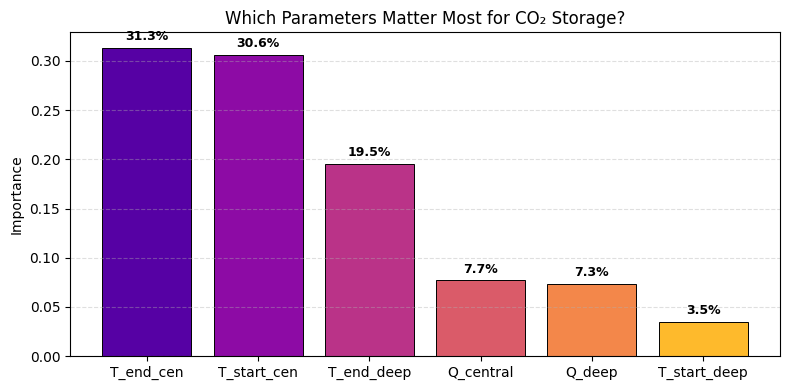

Ranking: ['T_end_cen', 'T_start_cen', 'T_end_deep', 'Q_central', 'Q_deep', 'T_start_deep']


In [10]:
# Cell 10 — Parameter Importance (Random Forest)
from sklearn.ensemble import RandomForestRegressor

if 'df_ok' not in dir() or len(df_ok) < 5:
    print('Run Cell 9 first (need ≥5 successful trials).')
else:
    param_cols = ['Q_deep','T_start_deep','T_end_deep','Q_central','T_start_cen','T_end_cen']
    X = df_ok[param_cols].values
    y = df_ok['co2_mt'].values
    rf = RandomForestRegressor(n_estimators=400, random_state=42)
    rf.fit(X, y)
    imp  = rf.feature_importances_
    sidx = np.argsort(imp)[::-1]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar([param_cols[i] for i in sidx], imp[sidx],
                  color=cm.plasma(np.linspace(0.15, 0.85, len(param_cols))),
                  edgecolor='k', lw=0.7)
    for bar, v in zip(bars, imp[sidx]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set(ylabel='Importance', title='Which Parameters Matter Most for CO₂ Storage?')
    ax.grid(True, ls='--', alpha=0.4, axis='y')
    plt.tight_layout()
    plt.savefig(f'{PYTHON_DIR}/bo_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Ranking:', [param_cols[i] for i in sidx])

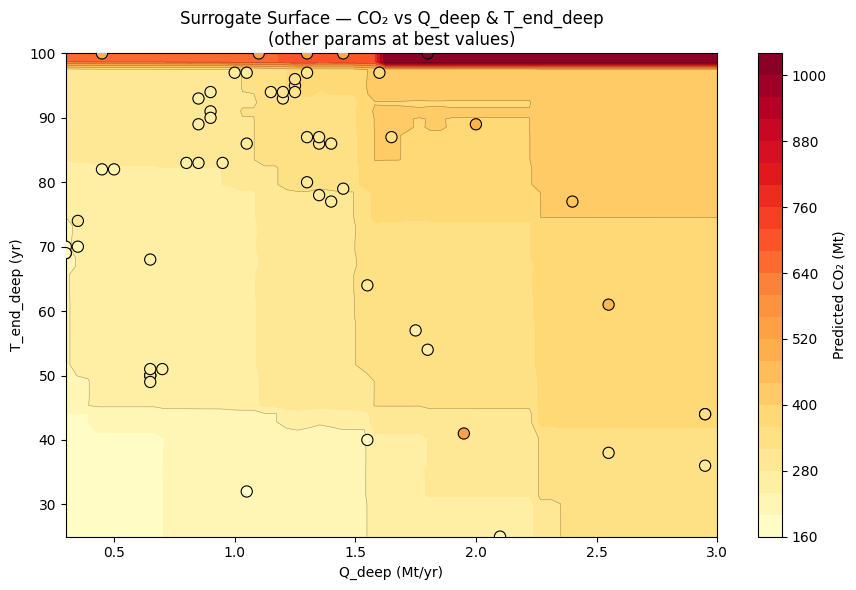

In [11]:
# Cell 11 — Surrogate Surface (Q_deep × T_end_deep)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

if 'df_ok' not in dir() or len(df_ok) < 5:
    print('Need ≥5 successful trials.')
else:
    param_cols = ['Q_deep','T_start_deep','T_end_deep','Q_central','T_start_cen','T_end_cen']
    X      = df_ok[param_cols].values
    y      = df_ok['co2_mt'].values
    scaler = StandardScaler()
    surr   = GradientBoostingRegressor(n_estimators=400, max_depth=4, random_state=42)
    surr.fit(scaler.fit_transform(X), y)
    best_row = df_ok.loc[df_ok['reward'].idxmax(), param_cols].values

    Q_g = np.linspace(*BOUNDS['Q_deep'], 60)
    T_g = np.linspace(*BOUNDS['T_end_deep'], 60)
    QQ, TT = np.meshgrid(Q_g, T_g)
    grid_pts = np.column_stack([
        QQ.ravel(), np.full(QQ.size, best_row[1]), TT.ravel(),
        np.full(QQ.size, best_row[3]), np.full(QQ.size, best_row[4]), np.full(QQ.size, best_row[5])
    ])
    Z = surr.predict(scaler.transform(grid_pts)).reshape(QQ.shape)

    fig, ax = plt.subplots(figsize=(9, 6))
    cf = ax.contourf(QQ, TT, Z, levels=25, cmap='YlOrRd')
    ax.contour(QQ, TT, Z, levels=12, colors='k', linewidths=0.4, alpha=0.35)
    plt.colorbar(cf, ax=ax, label='Predicted CO₂ (Mt)')
    ax.scatter(df_ok['Q_deep'], df_ok['T_end_deep'], c=df_ok['co2_mt'],
               cmap='YlOrRd', edgecolors='k', s=65, zorder=5, lw=0.8)
    if not df_feasible.empty:
        bs = df_feasible.loc[df_feasible['co2_mt'].idxmax()]
        ax.scatter([bs['Q_deep']], [bs['T_end_deep']], s=280, marker='*',
                   color='blue', zorder=6, label='Best feasible')
        ax.legend(fontsize=10)
    ax.set(xlabel='Q_deep (Mt/yr)', ylabel='T_end_deep (yr)',
           title=f'Surrogate Surface — CO₂ vs Q_deep & T_end_deep\n(other params at best values)')
    plt.tight_layout()
    plt.savefig(f'{PYTHON_DIR}/bo_surrogate.png', dpi=150, bbox_inches='tight')
    plt.show()

In [12]:
# Cell 12 — Full Results Table

if 'df_ok' not in dir() or df_ok.empty:
    print('Run Cell 9 first.')
else:
    cols = ['trial','Q_deep','T_start_deep','T_end_deep','Q_central',
            'T_start_cen','T_end_cen','co2_mt','max_bhp_bar',
            'max_sco2_bw1','max_sco2_bw2','is_feasible','cond1_breach','cond2_breach','reward']
    avail = [c for c in cols if c in df_ok.columns]
    df_show = df_ok[avail].copy()
    df_show['trial'] = df_show['trial'].astype(int) + 1
    df_show = df_show.sort_values('reward', ascending=False).reset_index(drop=True)
    # Percentage format for saturations
    for col in ['max_sco2_bw1','max_sco2_bw2']:
        if col in df_show.columns:
            df_show[col] = df_show[col].apply(lambda v: f'{v*100:.3f}%')

    def row_style(row):
        s = [''] * len(row)
        if row.get('cond1_breach') or row.get('cond2_breach'):
            s = ['background-color:#fff0f0'] * len(row)
        if row.get('is_feasible', False) and row.name == 0:
            s = ['background-color:#e8ffe8;font-weight:bold'] * len(row)
        return s

    fmt = {c: '{:.2f}' for c in ['Q_deep','Q_central','co2_mt','max_bhp_bar','reward']}
    display(df_show.style.apply(row_style, axis=1).format(fmt, na_rep='—'))

,trial,Q_deep,T_start_deep,T_end_deep,Q_central,T_start_cen,T_end_cen,co2_mt,max_bhp_bar,max_sco2_bw1,max_sco2_bw2,is_feasible,cond1_breach,cond2_breach,reward
0,59,1.00,16,97,0.40,18,39,307.40,635.52,0.000%,0.000%,False,True,False,-961.48
1,60,1.05,16,97,0.35,18,38,315.30,646.11,0.000%,0.000%,False,True,False,-994.17
2,49,1.30,15,97,1.05,15,25,369.50,700.23,0.000%,0.000%,False,True,False,-1161.20
3,52,1.35,17,87,0.60,17,25,330.20,705.39,0.000%,0.000%,False,True,False,-1177.13
4,55,1.35,17,78,0.55,14,37,305.65,705.99,0.000%,0.000%,False,True,False,-1178.98
5,47,1.25,14,94,1.05,14,28,379.70,712.93,0.000%,0.000%,False,True,False,-1200.40
6,48,1.25,15,96,1.00,15,27,379.70,712.93,0.000%,0.000%,False,True,False,-1200.40
7,50,1.35,15,86,1.05,16,25,342.95,714.11,0.000%,0.000%,False,True,False,-1204.04
8,51,1.30,17,87,0.60,17,25,342.95,714.11,0.000%,0.000%,False,True,False,-1204.04
9,53,1.40,17,86,0.55,17,25,340.00,714.49,0.000%,0.000%,False,True,False,-1205.22


In [13]:
# Cell 13 — Apply Best Feasible Parameters to well_plan.csv

if 'df_ok' not in dir() or df_ok.empty:
    print('Run Cell 9 first.')
else:
    if 'is_feasible' in df_ok.columns:
        df_feasible_local = df_ok[df_ok['is_feasible'] == True]
    else:
        df_feasible_local = df_ok[~df_ok['cond1_breach'] & ~df_ok['cond2_breach']]

    if df_feasible_local.empty:
        print(f'⚠️  No feasible trials yet (BHP ≤ {BHP_LIMIT_BAR:.0f} bar AND S_CO₂ < {S_CO2_THRESHOLD*100:.0f}%).')
        print('   Applying best-reward result instead (may violate constraints).')
        chosen = df_ok.loc[df_ok['reward'].idxmax()]
        mode = 'Best Reward (no feasible trial exists)'
    else:
        chosen = df_feasible_local.loc[df_feasible_local['co2_mt'].idxmax()]
        mode = 'Best Feasible (BHP + CO₂ constrained)'

    print(f'📝 Applying [{mode}]')
    print(f'   Deep: Q={chosen["Q_deep"]:.2f} Mt/yr  T=[{int(chosen["T_start_deep"])}->{int(chosen["T_end_deep"])}] yr')
    print(f'   Cen : Q={chosen["Q_central"]:.2f} Mt/yr  T=[{int(chosen["T_start_cen"])}->{int(chosen["T_end_cen"])}] yr')
    print(f'   Expected CO₂ : {chosen["co2_mt"]:.2f} Mt  |  Max BHP: {chosen["max_bhp_bar"]:.1f} bar')
    write_well_plan(chosen['Q_deep'],    int(chosen['T_start_deep']), int(chosen['T_end_deep']),
                    chosen['Q_central'], int(chosen['T_start_cen']),  int(chosen['T_end_cen']))
    print('\n✅ well_plan.csv updated. Run MATLAB for final validation.')

⚠️  No feasible trials yet (BHP ≤ 324 bar AND S_CO₂ < 15%).
   Applying best-reward result instead (may violate constraints).
📝 Applying [Best Reward (no feasible trial exists)]
   Deep: Q=1.00 Mt/yr  T=[16->97] yr
   Cen : Q=0.40 Mt/yr  T=[18->39] yr
   Expected CO₂ : 307.40 Mt  |  Max BHP: 635.5 bar

✅ well_plan.csv updated. Run MATLAB for final validation.


Surrogate model trained on 60 samples.
  R² (in-sample) : 1.0000
  MAE            : 0.06 Mt

  💾 Model saved  : /Users/apple/Desktop/study/programming/Matlab/Plugins/MRST-2026a/core/examples/data/Johansen/python/johansen_surrogate_model.pkl
  💾 Scaler saved : /Users/apple/Desktop/study/programming/Matlab/Plugins/MRST-2026a/core/examples/data/Johansen/python/johansen_surrogate_scaler.pkl
  💾 BHP model    : /Users/apple/Desktop/study/programming/Matlab/Plugins/MRST-2026a/core/examples/data/Johansen/python/johansen_bhp_surrogate_model.pkl  (R²=1.0000)


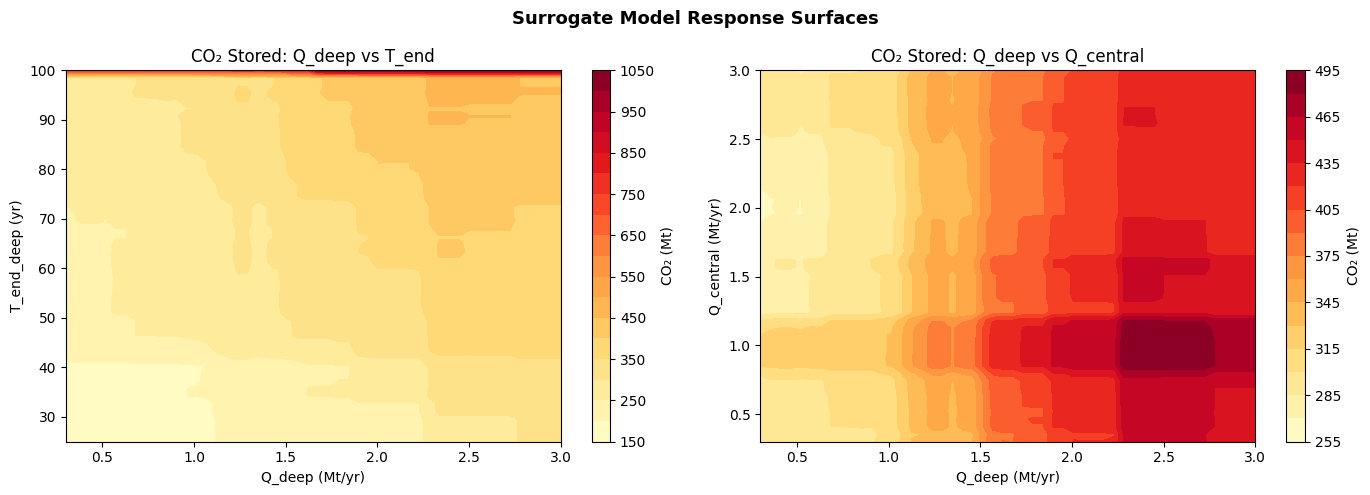


✅ Surrogate model exported. Use joblib.load() to reload.


In [14]:
# Cell 14 — Surrogate Model Export (Pickle + Response Surface)
#
# Trains a final surrogate model on ALL feasible trials and saves it for reuse.
# This is the trained model you can use to predict CO₂ storage for new well plans
# without running MATLAB again.

import joblib

if 'df_ok' not in dir() or len(df_ok) < 5:
    print('Need ≥5 successful trials for surrogate export.')
else:
    from sklearn.ensemble import GradientBoostingRegressor
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import r2_score, mean_absolute_error

    param_cols = ['Q_deep','T_start_deep','T_end_deep','Q_central','T_start_cen','T_end_cen']
    X = df_ok[param_cols].values
    y = df_ok['co2_mt'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train surrogate (GBR is robust for small datasets)
    surrogate = GradientBoostingRegressor(
        n_estimators=500, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42
    )
    surrogate.fit(X_scaled, y)

    # In-sample metrics (leave-one-out would be better but expensive)
    y_pred = surrogate.predict(X_scaled)
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)

    print(f'Surrogate model trained on {len(y)} samples.')
    print(f'  R² (in-sample) : {r2:.4f}')
    print(f'  MAE            : {mae:.2f} Mt')

    # Save
    model_path = f'{PYTHON_DIR}/johansen_surrogate_model.pkl'
    scaler_path = f'{PYTHON_DIR}/johansen_surrogate_scaler.pkl'
    joblib.dump(surrogate, model_path)
    joblib.dump(scaler, scaler_path)
    print(f'\n  💾 Model saved  : {model_path}')
    print(f'  💾 Scaler saved : {scaler_path}')

    # Also train a BHP surrogate for constraint prediction
    if 'max_bhp_bar' in df_ok.columns:
        y_bhp = df_ok['max_bhp_bar'].values
        bhp_surrogate = GradientBoostingRegressor(
            n_estimators=500, max_depth=4, learning_rate=0.05,
            subsample=0.8, random_state=42
        )
        bhp_surrogate.fit(X_scaled, y_bhp)
        bhp_r2 = r2_score(y_bhp, bhp_surrogate.predict(X_scaled))
        bhp_path = f'{PYTHON_DIR}/johansen_bhp_surrogate_model.pkl'
        joblib.dump(bhp_surrogate, bhp_path)
        print(f'  💾 BHP model    : {bhp_path}  (R²={bhp_r2:.4f})')

    # ── Quick response surface for verification ──────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Surface 1: Q_deep vs T_end_deep
    best_params = df_ok.loc[df_ok['reward'].idxmax(), param_cols].values
    Q_g = np.linspace(*BOUNDS['Q_deep'], 50)
    T_g = np.linspace(*BOUNDS['T_end_deep'], 50)
    QQ, TT = np.meshgrid(Q_g, T_g)
    grid = np.column_stack([QQ.ravel(), np.full(QQ.size, best_params[1]), TT.ravel(),
                            np.full(QQ.size, best_params[3]), np.full(QQ.size, best_params[4]),
                            np.full(QQ.size, best_params[5])])
    Z = surrogate.predict(scaler.transform(grid)).reshape(QQ.shape)
    cf = axes[0].contourf(QQ, TT, Z, levels=20, cmap='YlOrRd')
    plt.colorbar(cf, ax=axes[0], label='CO₂ (Mt)')
    axes[0].set(xlabel='Q_deep (Mt/yr)', ylabel='T_end_deep (yr)',
                title='CO₂ Stored: Q_deep vs T_end')

    # Surface 2: Q_deep vs Q_central
    Qd_g = np.linspace(*BOUNDS['Q_deep'], 50)
    Qc_g = np.linspace(*BOUNDS['Q_central'], 50)
    QQd, QQc = np.meshgrid(Qd_g, Qc_g)
    grid2 = np.column_stack([QQd.ravel(), np.full(QQd.size, best_params[1]),
                             np.full(QQd.size, best_params[2]), QQc.ravel(),
                             np.full(QQd.size, best_params[4]), np.full(QQd.size, best_params[5])])
    Z2 = surrogate.predict(scaler.transform(grid2)).reshape(QQd.shape)
    cf2 = axes[1].contourf(QQd, QQc, Z2, levels=20, cmap='YlOrRd')
    plt.colorbar(cf2, ax=axes[1], label='CO₂ (Mt)')
    axes[1].set(xlabel='Q_deep (Mt/yr)', ylabel='Q_central (Mt/yr)',
                title='CO₂ Stored: Q_deep vs Q_central')

    plt.suptitle('Surrogate Model Response Surfaces', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{PYTHON_DIR}/bo_surrogate_export.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n✅ Surrogate model exported. Use joblib.load() to reload.')

In [15]:
# Cell 15 — Emergency Restore
# Run ONLY if you want to undo all BO changes to well_plan.csv

# restore_well_plan()
print('Uncomment restore_well_plan() to undo all changes.')

Uncomment restore_well_plan() to undo all changes.
